In [161]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings(action='ignore')
# 데이터 전처리
from sklearn.model_selection import train_test_split

# 모델 패키지
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 모델 평가
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rc('font', family='applegothic')

In [200]:
data = pd.read_csv("/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/heart_failure_clinical_records_dataset.csv")

In [201]:
print("data 갯수 : ",len(data))
data.head()

data 갯수 :  299


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [202]:
data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [ ]:
# for heart disease data


Spectral_entropy : 신호의 주파수가 얼마나 불균일한가를 나타내는 척도

Frequency_band_energy : 원본 신호를 주파수 대역으로 나누었을때, 가지는 에너지의 세기

Inter-Arrival time : 연속된 두 패킷의 사이 시간

<Axes: xlabel='frequency_band_energy', ylabel='spectral_entropy'>

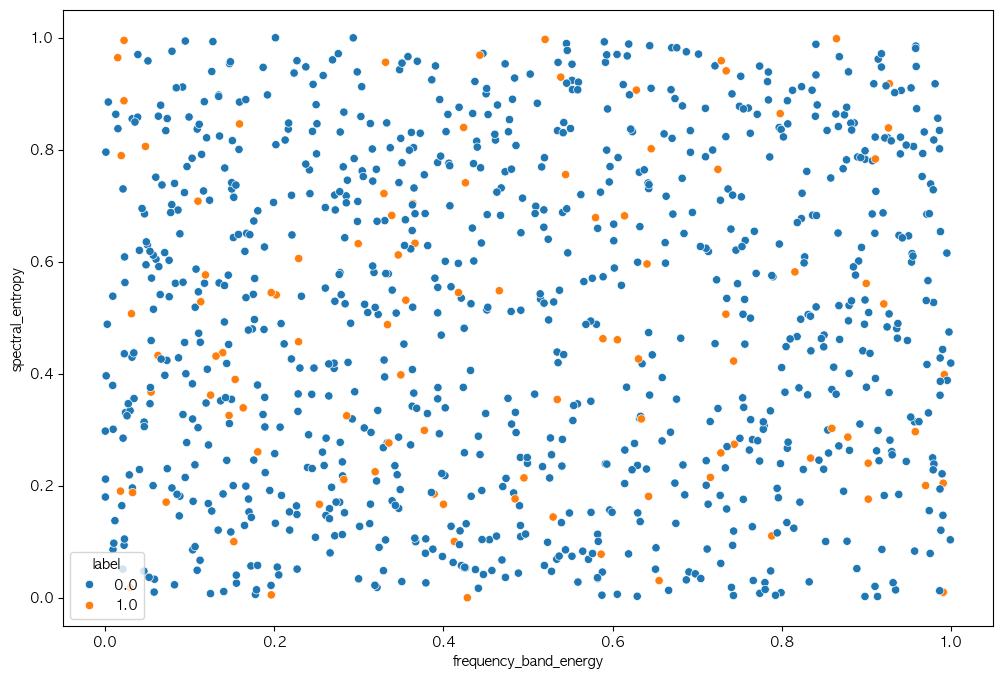

In [48]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='frequency_band_energy', y='spectral_entropy', hue='label', data=data)

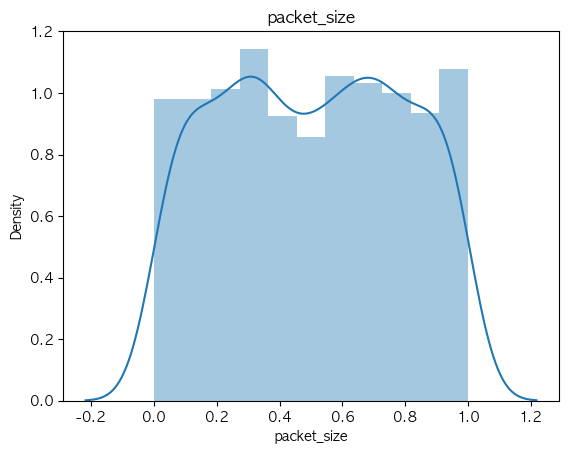

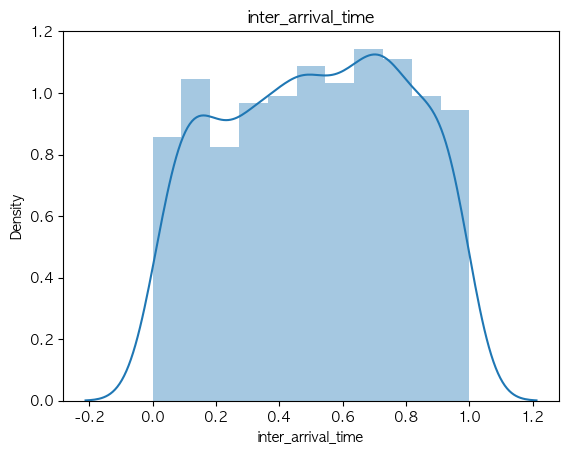

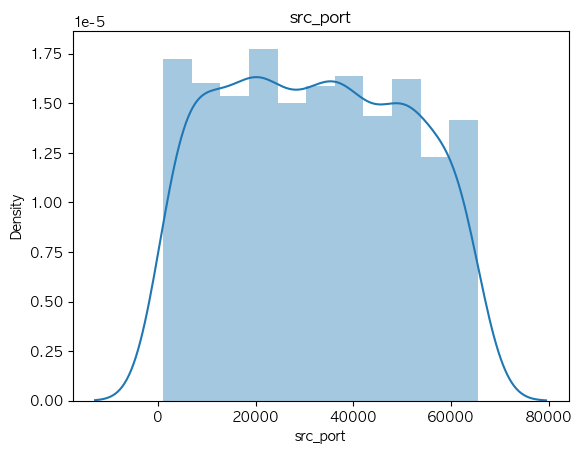

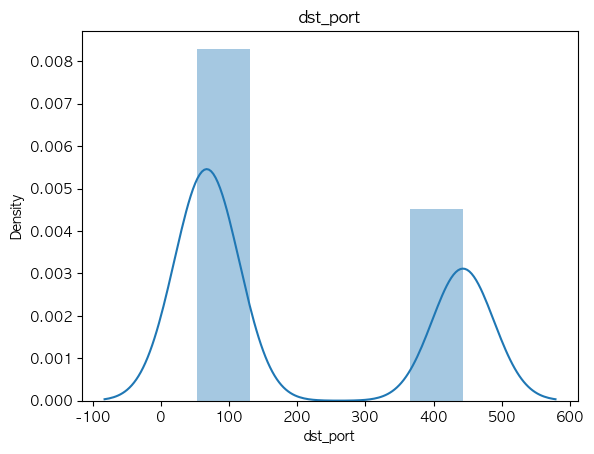

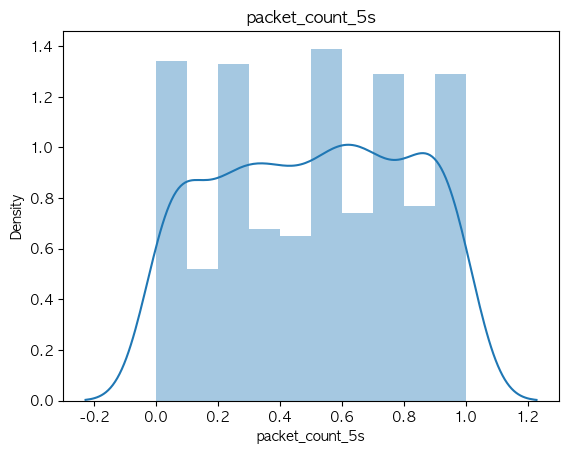

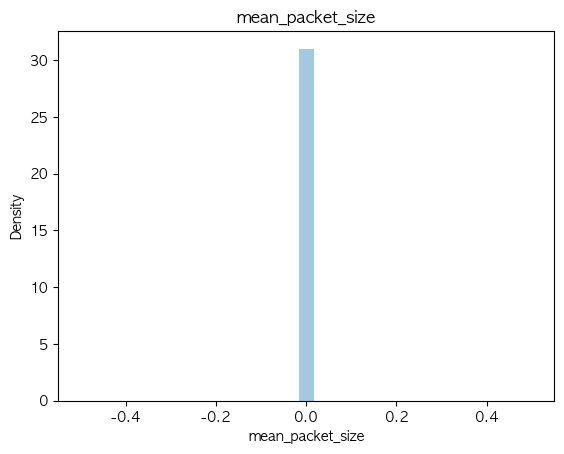

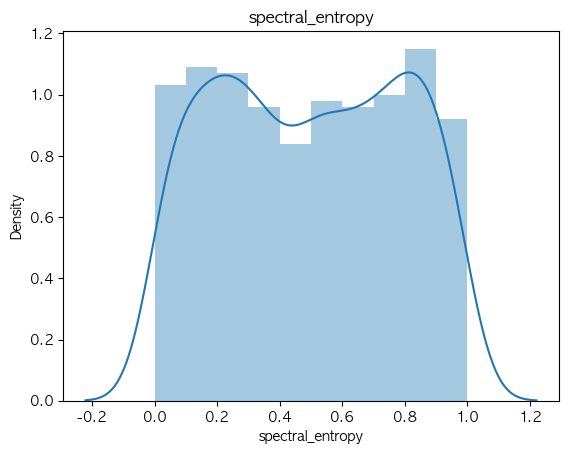

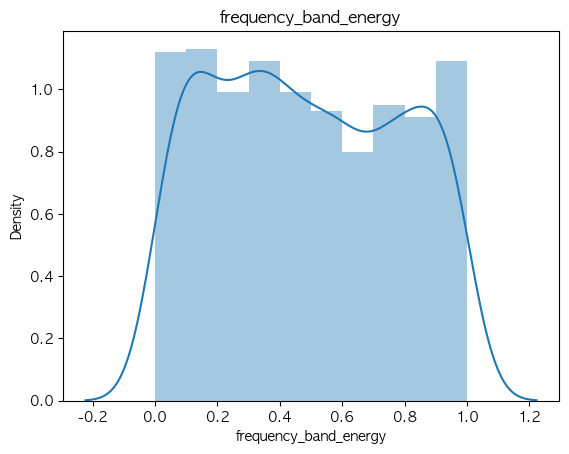

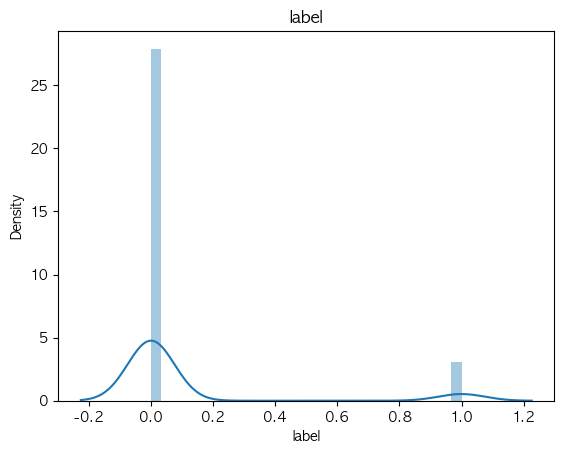

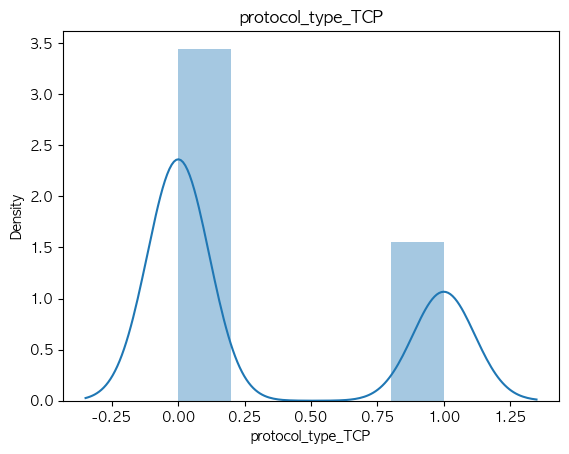

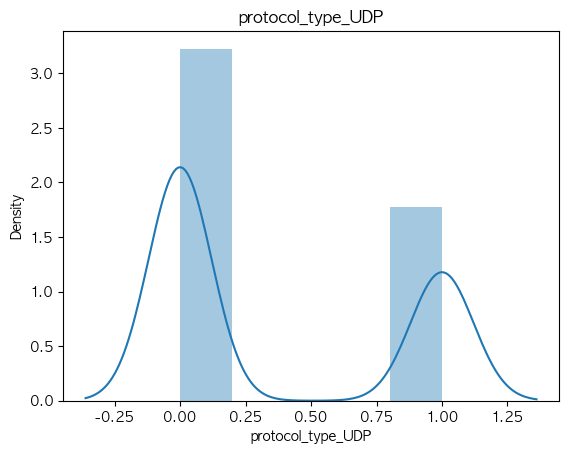

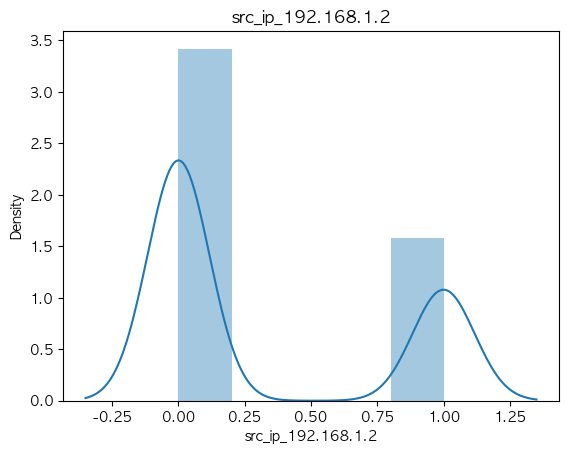

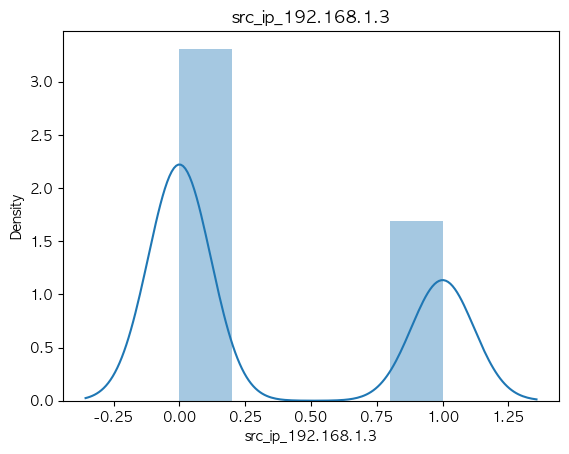

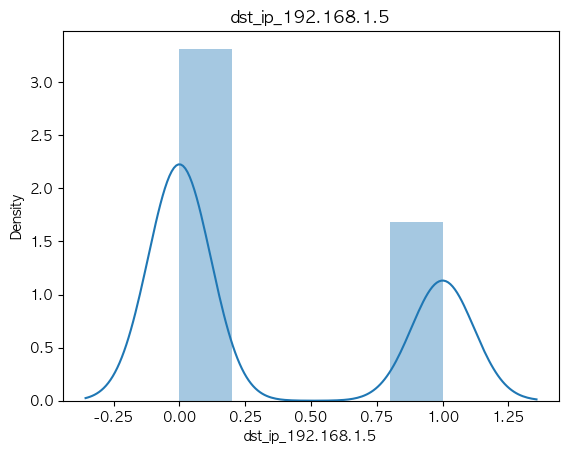

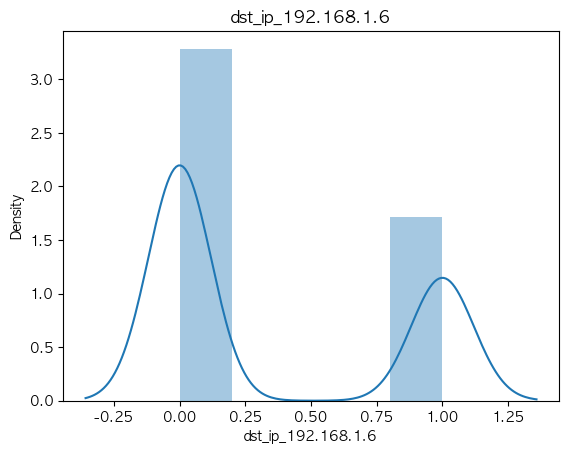

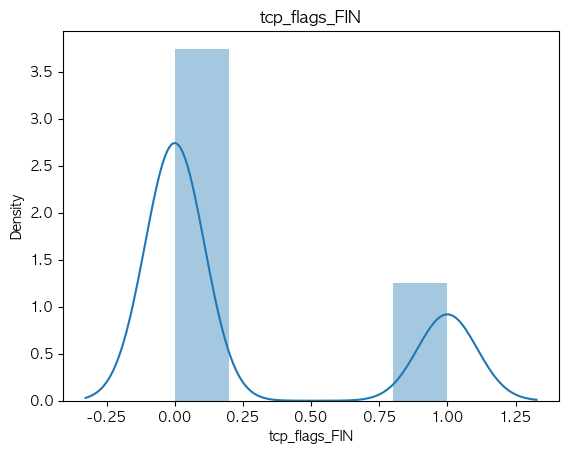

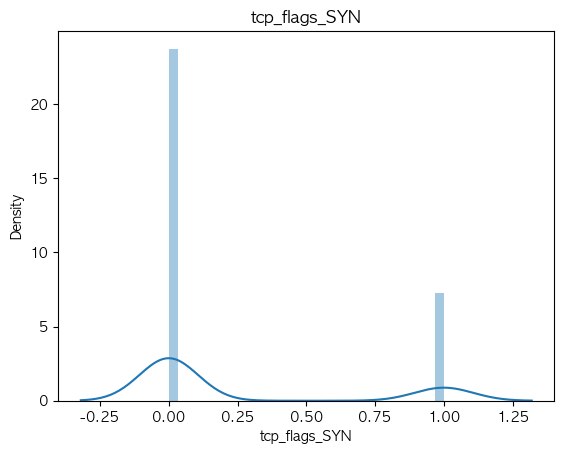

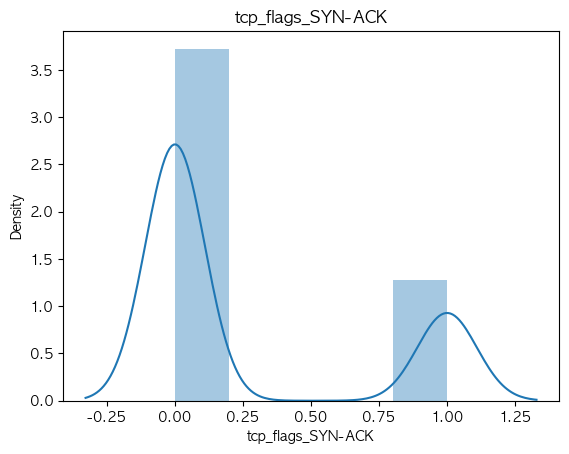

In [51]:
for col in data:
    sns.distplot(data.loc[data[col].notnull(), col])
    plt.title(col)
    plt.show()

In [5]:
target = data['label']
target.count()

1000

label
0.0    900
1.0    100
Name: count, dtype: int64


<Axes: title={'center': 'class distribution'}, xlabel='count', ylabel='label'>

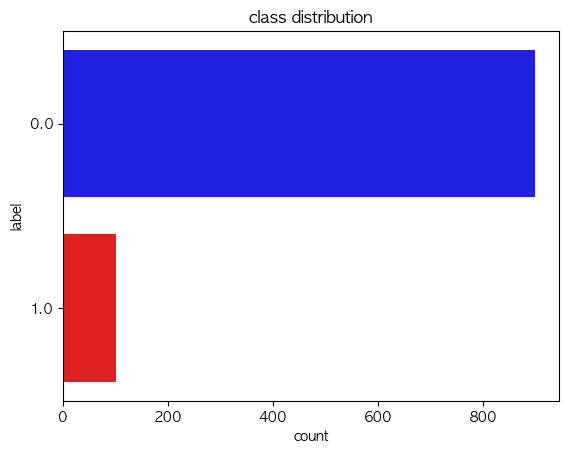

In [23]:
print(target.value_counts())
plt.title("class distribution")
sns.countplot(y=data['label'], data=data, palette=['blue','red'])

In [117]:
x = data[data.columns.difference(['label', 'mean_packet_size','src_ip_192.168.1.3','src_ip_192.168.1.2','dst_ip_192.168.1.6','dst_ip_192.168.1.5','dst_port','src_port','protocol_type_TCP',
                                  'tcp_flags_SYN-ACK','tcp_flags_SYN','tcp_flags_FIN'])]
#x = data[data.columns.difference(['label','mean_packet_size'])]
y = data['label']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.1, random_state=42)

In [118]:
y_test.value_counts()

label
0.0    94
1.0     6
Name: count, dtype: int64

In [119]:
print(len(data['src_port'].unique()))
print(len(data['dst_port'].unique()))

995
3


In [120]:
x

,frequency_band_energy,inter_arrival_time,packet_count_5s,packet_size,protocol_type_UDP,spectral_entropy
0,0.534891,0.620362,0.857143,0.405154,True,0.834066
1,0.990757,0.741288,0.785714,0.527559,True,0.147196
2,0.031781,0.485116,0.285714,0.226199,True,0.855192
3,0.169958,0.450965,0.142857,0.573372,False,0.153220
4,0.552053,0.888740,0.714286,0.651396,False,0.923916
...,...,...,...,...,...,...
995,0.402062,0.078032,0.428571,0.103794,True,0.339083
996,0.418902,0.048901,0.928571,0.727989,False,0.094822
997,0.441276,0.731936,0.928571,0.952756,True,0.016880
998,0.806790,0.655933,0.071429,0.322835,False,0.887533


In [178]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled

x_train_sc, x_test_sc, y_train, y_test = train_test_split(x,y, test_size=0.1, random_state=42)

# PCA

In [128]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
result = pca.fit_transform(x_scaled)

print(pca.explained_variance_ratio_)
result =pd.DataFrame(result, columns=['feature1', 'feature2'])

[0.18983538 0.18162964]


In [133]:
result['label'] = y
result

,feature1,feature2,label
0,0.256027,0.132071,0.0
1,0.907065,-0.329225,0.0
2,1.105792,-0.541200,0.0
3,-0.034365,-0.965134,0.0
4,-1.393503,0.481497,0.0
...,...,...,...
995,1.877808,-0.030856,0.0
996,-1.189299,-0.162075,0.0
997,-0.489576,-1.999514,0.0
998,0.511841,1.612595,0.0


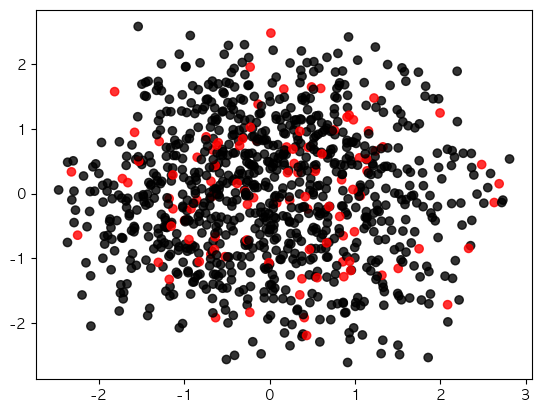

In [160]:
color_map = {0:'black', 1:'red'}
colors = result['label'].map(color_map)
plt.scatter(x=result['feature1'], y=result['feature2'], c = colors, alpha=0.8)

In [150]:
# 재구성 기반은 이상치는 다시 복구가 안될 것이다 라는 전제
x_proj = pca.inverse_transform(pca.fit_transform(x_scaled))
recon_error = ( (x_scaled - x_proj) **2 ).sum(axis=1)
thre = np.percentile(recon_error.sort_values(ascending=False), 90)

pred_pca = (recon_error >= thre).astype(int)
pred_pca

print(classification_report(y, pred_pca, digits=3))

              precision    recall  f1-score   support

         0.0      0.903     0.903     0.903       900
         1.0      0.130     0.130     0.130       100

    accuracy                          0.826      1000
   macro avg      0.517     0.517     0.517      1000
weighted avg      0.826     0.826     0.826      1000



# KNN

In [179]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', metric='minkowski')
knn.fit(x_train_sc, y_train)

KNeighborsClassifier(weights='distance')

In [190]:
knn_pred_train = knn.predict(x_train_sc)
knn_pred_test = knn.predict(x_test_sc)

print(metrics.accuracy_score(y_train, knn_pred_train))
print(metrics.accuracy_score(y_test, knn_pred_test))

1.0
0.92


[[92  2]
 [ 6  0]]


<Axes: >

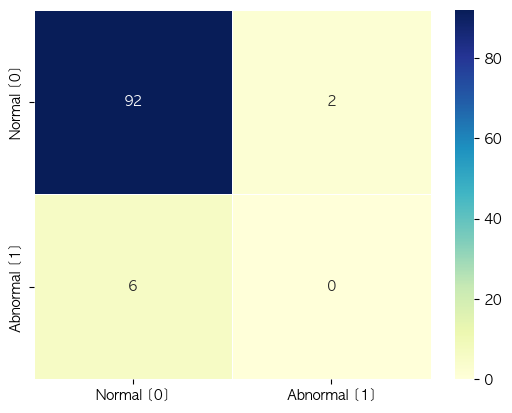

In [199]:
cm = confusion_matrix(y_test, knn_pred_test)

# col : 모델 예측 
# raw : 실제
print(cm)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")